# Model comparison for financial sentiment analysis

This notebook presents a comparative analysis of two different machine learning approaches for financial sentiment classification. Using a common dataset of labeled financial sentences, the project evaluates a classical TF-IDF representation combined with Logistic Regression and a semantic embedding-based approach using Sentence Transformers.

The models are compared using standard classification metrics, including accuracy, macro F1-score, precision, recall, and confusion matrices. Particular attention is dedicated to the analysis of classification errors and to the differences between lexical and semantic text representations in the context of financial language.

The main objective is to investigate whether embedding-based representations provide meaningful improvements over a simpler and more interpretable TF-IDF baseline for financial sentiment analysis.


## 1. Data Import

The dataset used for this analysis was downloaded as a CSV file from [Kaggle](https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis) and stored locally in the `./data/raw` directory.

According to the dataset description provided on Kaggle, the dataframe was created by merging two financial sentiment datasets: FiQA and Financial PhraseBank.

The resulting dataset contains 5,842 financial sentences labeled according to their sentiment (`negative`, `neutral`, or `positive`) depending on the type of financial information conveyed by each sentence.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sentence_transformers import SentenceTransformer

pd.set_option("display.max_colwidth", None)

# Defining paths
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "data", "data.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

# Importing raw data
df = pd.read_csv(DATA_PATH)
df = df.reset_index(names = "sentence_id")
df.head(10)

,sentence_id,Sentence,Sentiment
0,0,"The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a Communities Platform , location relevant multimedia content and a new and powerful commercial model .",positive
1,1,"$ESI on lows, down $1.50 to $2.50 BK a real possibility",negative
2,2,"For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .",positive
3,3,"According to the Finnish-Russian Chamber of Commerce , all the major construction companies of Finland are operating in Russia .",neutral
4,4,"The Swedish buyout firm has sold its remaining 22.4 percent stake , almost eighteen months after taking the company public in Finland .",neutral
5,5,$SPY wouldn't be surprised to see a green close,positive
6,6,Shell's $70 Billion BG Deal Meets Shareholder Skepticism,negative
7,7,"SSH COMMUNICATIONS SECURITY CORP STOCK EXCHANGE RELEASE OCTOBER 14 , 2008 AT 2:45 PM The Company updates its full year outlook and estimates its results to remain at loss for the full year .",negative
8,8,Kone 's net sales rose by some 14 % year-on-year in the first nine months of 2008 .,positive
9,9,"The Stockmann department store will have a total floor space of over 8,000 square metres and Stockmann 's investment in the project will have a price tag of about EUR 12 million .",neutral


## 2. Data Check

Before proceeding with the analysis, the dataset must be inspected for potential quality issues such as duplicate observations, missing values, and class imbalance.

Because the dataset originates from multiple sources, duplicate sentences may be present. This is particularly important in a supervised learning setting, since duplicate observations shared between training and test sets may lead to train-test contamination and artificially inflated evaluation metrics. To avoid this issue, duplicate sentences will be removed before splitting the dataset.

The class distribution is also inspected in order to evaluate the degree of imbalance between sentiment categories, which may influence model performance and evaluation metrics.

Dropped duplicates. New length of df: 5322

           Absolute  Relative
Sentiment                    
neutral        2878  0.540774
positive       1852  0.347989
negative        592  0.111236


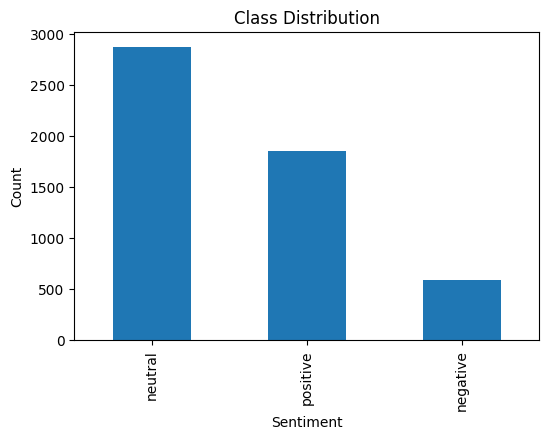

In [73]:
if len(df) != len(df.Sentence.unique()):
    df = df.drop_duplicates(subset = "Sentence", keep = "first")
    print(f"Dropped duplicates. New length of df: {len(df)}\n")

if df.isna().sum().sum() > 0:
    df = df.dropna(subset = ["Sentence", "Sentiment"])
    print(f"Dropped missing values. New length of df: {len(df)}\n")

freqs = pd.DataFrame({'Absolute': df["Sentiment"].value_counts(), 
                      'Relative': df["Sentiment"].value_counts(normalize=True)})
print(freqs)


fig, ax = plt.subplots(figsize=(6,4))

df["Sentiment"].value_counts().plot(kind="bar", ax=ax)

ax.set_title("Class Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")

plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), bbox_inches='tight')
plt.show()

As expected, the dataset contained a substantial number of duplicate sentences. After removing duplicates, the dataset size decreased from 5,842 to 5,322 observations.

The class distribution also reveals a significant imbalance between sentiment categories. Neutral sentences represent more than half of the dataset, while negative observations constitute the smallest class. This imbalance may affect model performance, particularly on minority classes, and should therefore be considered when interpreting the evaluation metrics.

## 3. Preprocessing

In this project, only minimal text preprocessing was applied. Sentences were converted to string format and leading/trailing whitespace was removed.

More aggressive preprocessing techniques such as stemming, lemmatization, stopword removal, or number removal were intentionally avoided in order to preserve potentially relevant financial information. In financial sentiment analysis, numbers, negations, and domain-specific terminology may carry important semantic signals that could be lost through excessive text normalization.

In [74]:
df["Sentence"] = (
    df["Sentence"]
    .astype(str)
    .str.strip()
)

## 4. Train-Test split

The dataset was divided into training and test sets with an 80/20 ratio. A stratified sampling was used in order to preserve the original class distribution across both subsets.

This method is particularly important in the presence of class imbalance, since it ensures that the training and test sets contain the same proportion of `negative`, `neutral`, and `positive` sentences as the original dataset, helping provide a more reliable and fair evaluation of model performance.

In [75]:
x_train, x_test, y_train, y_test = train_test_split(
    df["Sentence"],
    df["Sentiment"],
    test_size = 0.2,
    stratify = df["Sentiment"],
    random_state = 42
)
print(f"Train set size: {len(x_train)}")
print(f"Test set size: {len(x_test)}")
print("\n")


train_test_df = pd.DataFrame({
    "Sentiment": ["neutral", "positive", "negative"],
    "Train set distribution": y_train.value_counts(normalize = True).values,
    "Test set distribution": y_test.value_counts(normalize = True).values
})
print(train_test_df)

Train set size: 4257
Test set size: 1065


  Sentiment  Train set distribution  Test set distribution
0   neutral                0.540756               0.540845
1  positive                0.347898               0.348357
2  negative                0.111346               0.110798


## 5. TF-IDF model
This section implements the first sentiment classification approach based on TF-IDF vectorization and Logistic Regression. The TF-IDF representation converts each sentence into a sparse vector built from weighted unigram and bigram frequencies.

A Logistic Regression classifier is then trained on these vectors in order to predict the sentiment label associated with each sentence.

### 5.1 Model intuition
TF-IDF is a sparse bag-of-words representation where each sentence is represented as a vector of weighted word frequencies. These weights are determined by combining two different measures:
1. Term Frequency (TF), which represents the relative frequency of a word within a sentence;
2. Inverse Document Frequency (IDF), which rewards terms that are rare across the entire corpus.

By multiplying this two metrics, TF-IDF assign a higher score to words that are frequent in a specific sentence but uncommon in the corpus as a whole. As a result, common but less informative words receive lower importance, while terms carrying more discriminative information are emphasized.

However, TF-IDF representations are purely lexical and do not capture semantic similarity or contextual information between words and sentences.

### 5.2 Implementation

In [76]:
'''
The TF-IDF representation is implemented using `TfidfVectorizer` from `scikit-learn`,
which converts textual data into sparse numerical vectors based on weighted unigram and bigram frequencies.

The classification task is then performed using a `LogisticRegression` model from `scikit-learn`,
trained on the vectorized sentences to predict the corresponding sentiment labels.
'''

tfidf = TfidfVectorizer(
    lowercase = True,
    ngram_range = (1, 2),
    max_features = 20000
)

x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

print(f"TF-IDF train set shape: {x_train_tfidf.shape}")
print(f"TF-IDF test set shape: {x_test_tfidf.shape}\n")

clf = LogisticRegression(
    max_iter = 1000,
    class_weight = "balanced",
    random_state = 42
)

clf.fit(x_train_tfidf, y_train)

print(f"Train set score: {clf.score(x_train_tfidf, y_train)}")
print(f"Test set score: {clf.score(x_test_tfidf, y_test)}")

TF-IDF train set shape: (4257, 20000)
TF-IDF test set shape: (1065, 20000)

Train set score: 0.9332863518910031
Test set score: 0.7323943661971831


The TF-IDF model achieves a high training accuracy together with a lower test accuracy, suggesting some overfitting. This behavior is relatively common in sparse high-dimensional representations like TF-IDF, where the model can learn highly specific lexical patterns from the training data that may not generalize perfectly to unseen sentences.

Nevertheless, the test performance indicates that the model is able to capture a substantial amount of sentiment-related lexical information from financial text.

### 5.3 Results
The predictions on the test set are stored in a dataframe, allowing direct comparison between true and predicted labels for each sentence. This structure facilitates further evaluation and error analysis.

In [77]:
y_pred_tfidf = clf.predict(x_test_tfidf)
results_tfidf_df = pd.DataFrame({
    "sentence_id": df.loc[x_test.index, "sentence_id"],
    "sentence": x_test,
    "true_label": y_test,
    "predicted_label_tfidf": y_pred_tfidf
})
results_tfidf_df.head(10)

,sentence_id,sentence,true_label,predicted_label_tfidf
3291,3291,"This implementation is very important to the operator , since it is about to launch its Fixed-to-Mobile convergence service in Brazil see Brazil : 8 May 2006 : .",neutral,neutral
4532,4532,"RAPALA TOURNAMENT FISHING : With all the major titles already out for the holidays , bargain-priced games such as Rapala aim for a smaller audience .",neutral,neutral
65,65,Most bullish stocks on Twitter during this dip. $YHOO $GDX $GOOGL $STZ $GOLD $EW $VZ $CELG $SBUX $SCTY more: https://t.co/iuZJelfwt3,positive,positive
1652,1652,The bank sees a potential for Getinge share to rise .,positive,positive
5372,5372,Finnish Componenta has published its new long-term strategy for the period 2011-2015 with the aim of growing together with its customers .,neutral,positive
1248,1248,Metsaliitto said that it will book a minor gain of less than EUR1 .0 m from the transaction .,positive,positive
3814,3814,"Before FKI , John Jiang has worked in several general manager or senior business consultant positions for international companies in China .",neutral,neutral
158,158,"In future , the company intends to look for know-how from outside the company and to cooperate with other actors in the sector .",positive,neutral
2180,2180,Kirsi Rantanen was previously development director for HK Ruokatalo 's poultry business .,neutral,neutral
1125,1125,"Coca-Cola was the market leader of manufacturers with a market share of 36.9 % , down 2.2 % from the corresponding period in 2004-2005 .",negative,neutral


## 6. Embedding-based model

Sparse vector representations are now replaced with dense semantic sentence embeddings generated using the `all-MiniLM-L6-v2` Sentence Transformer model.

As previously mentioned, the model is evaluated on the same test set used for the TF-IDF baseline to ensure a fair comparison between the two approaches.


### 6.1 Model Intuition

Sentence embeddings represent sentences as dense numerical vectors in which semantic and contextual information is encoded. Unlike sparse lexical representations such as TF-IDF, embeddings aim to capture similarities in meaning between different sentences, even when different words or expressions are used.

In this representation space, semantically similar sentences are mapped to nearby vectors. This allows machine learning models to exploit contextual and semantic relations that are typically not captured by purely frequency-based approaches.

### 6.2 Model implementation

In [78]:
'''
The sentence embedding representation is implemented using the `SentenceTransformer` library,
which provides pre-trained models to convert sentences into dense vector representations.

In this case, the "all-MiniLM-L6-v2" model is used.
This is a compact and efficient model that generates 384-dimensional vectors for each sentence.

As with the TF-IDF representation, a `LogisticRegression` model is trained on the sentence embeddings to predict the sentiment labels.
'''

model = SentenceTransformer("all-MiniLM-L6-v2")

x_train_emb = model.encode(
    x_train.tolist(),
    show_progress_bar=True
    )
x_test_emb = model.encode(
    x_test.tolist(),
    show_progress_bar=True
)

print(f"\nEmbeddings train set shape: {x_train_emb.shape}")
print(f"Embeddings test set shape: {x_test_emb.shape}\n")

clf_emb = LogisticRegression(
    max_iter = 1000,
    class_weight = "balanced",
    random_state = 42
)

clf_emb.fit(x_train_emb, y_train)

print(f"Train set score: {clf_emb.score(x_train_emb, y_train)}")
print(f"Test set score: {clf_emb.score(x_test_emb, y_test)}")

Batches: 100%|██████████| 34/34 [00:05<00:00,  6.17it/s]



Embeddings train set shape: (4257, 384)
Embeddings test set shape: (1065, 384)

Train set score: 0.7733145407564013
Test set score: 0.7446009389671362


Compared with the TF-IDF baseline, the embedding-based model achieves a lower training accuracy but a slightly higher test accuracy. This suggests better generalization capabilities and a lower tendency to overfit the training data.

Unlike sparse lexical representations, sentence embeddings provide more compact semantic representations that allow the classifier to capture contextual similarities between sentences, even when different words or expressions are used.


### 6.3 Results

In [79]:
y_pred_embedding = clf_emb.predict(x_test_emb)

results_embedding_df = pd.DataFrame({
    "sentence_id": df.loc[x_test.index, "sentence_id"],
    "sentence": x_test,
    "true_label": y_test,
    "predicted_label_embedding": y_pred_embedding
})
results_embedding_df.head(10)

,sentence_id,sentence,true_label,predicted_label_embedding
3291,3291,"This implementation is very important to the operator , since it is about to launch its Fixed-to-Mobile convergence service in Brazil see Brazil : 8 May 2006 : .",neutral,neutral
4532,4532,"RAPALA TOURNAMENT FISHING : With all the major titles already out for the holidays , bargain-priced games such as Rapala aim for a smaller audience .",neutral,neutral
65,65,Most bullish stocks on Twitter during this dip. $YHOO $GDX $GOOGL $STZ $GOLD $EW $VZ $CELG $SBUX $SCTY more: https://t.co/iuZJelfwt3,positive,negative
1652,1652,The bank sees a potential for Getinge share to rise .,positive,positive
5372,5372,Finnish Componenta has published its new long-term strategy for the period 2011-2015 with the aim of growing together with its customers .,neutral,positive
1248,1248,Metsaliitto said that it will book a minor gain of less than EUR1 .0 m from the transaction .,positive,positive
3814,3814,"Before FKI , John Jiang has worked in several general manager or senior business consultant positions for international companies in China .",neutral,neutral
158,158,"In future , the company intends to look for know-how from outside the company and to cooperate with other actors in the sector .",positive,neutral
2180,2180,Kirsi Rantanen was previously development director for HK Ruokatalo 's poultry business .,neutral,neutral
1125,1125,"Coca-Cola was the market leader of manufacturers with a market share of 36.9 % , down 2.2 % from the corresponding period in 2004-2005 .",negative,neutral


## 7. Model comparison
This section compares the results of the two sentiment classification approaches. The comparison includes both quantitative evaluation metrics and a visual analysis of classification errors through confusion matrices. Special attention is dedicated to the behavior of the models on the minority `negative` class, which represents the most challenging category in the dataset.

### 7.1 Merging predictions
To enable a direct comparison between the two approaches, the predictions generated by both models are merged into a single dataframe. This allows a sentence-level analysis of differences between TF-IDF and embedding-based predictions.

In [80]:
results = results_tfidf_df.merge(
    results_embedding_df[["sentence_id", "predicted_label_embedding"]],
    on = "sentence_id"
)
display(results.head(10))

with open(os.path.join(OUTPUT_DIR, "results_summary.csv"), "w") as f:
    results.to_csv(f, index=False)

,sentence_id,sentence,true_label,predicted_label_tfidf,predicted_label_embedding
0,3291,"This implementation is very important to the operator , since it is about to launch its Fixed-to-Mobile convergence service in Brazil see Brazil : 8 May 2006 : .",neutral,neutral,neutral
1,4532,"RAPALA TOURNAMENT FISHING : With all the major titles already out for the holidays , bargain-priced games such as Rapala aim for a smaller audience .",neutral,neutral,neutral
2,65,Most bullish stocks on Twitter during this dip. $YHOO $GDX $GOOGL $STZ $GOLD $EW $VZ $CELG $SBUX $SCTY more: https://t.co/iuZJelfwt3,positive,positive,negative
3,1652,The bank sees a potential for Getinge share to rise .,positive,positive,positive
4,5372,Finnish Componenta has published its new long-term strategy for the period 2011-2015 with the aim of growing together with its customers .,neutral,positive,positive
5,1248,Metsaliitto said that it will book a minor gain of less than EUR1 .0 m from the transaction .,positive,positive,positive
6,3814,"Before FKI , John Jiang has worked in several general manager or senior business consultant positions for international companies in China .",neutral,neutral,neutral
7,158,"In future , the company intends to look for know-how from outside the company and to cooperate with other actors in the sector .",positive,neutral,neutral
8,2180,Kirsi Rantanen was previously development director for HK Ruokatalo 's poultry business .,neutral,neutral,neutral
9,1125,"Coca-Cola was the market leader of manufacturers with a market share of 36.9 % , down 2.2 % from the corresponding period in 2004-2005 .",negative,neutral,neutral


### 7.2 Metrics comparison
The following analysis compares the overall predictive performance of the two models using the following evaluation metrics:

* **Accuracy**: measures the proportion of correctly classified sentences over the total number of observations;
* **Precision**: measures how many sentences predicted as belonging to a class are actually correct;
* **Recall**: measures how many true examples of a class are correctly identified by the model;
* **F1-score**: combines precision and recall into a single metric, rewarding models that perform well on both measures. The **Macro F1-score** is computed as the average F1-score across all classes, assigning the same importance to each of them.

In addition, normalized confusion matrices are used to visualize classification behavior. Each row corresponds to the true class distribution, while each column represents the predicted labels. This normalization allows for a direct comparison of error patterns across classes and between models.



,Model,Accuracy,Macro F1,Negative Precision,Negative Recall,Negative F1,Neutral Precision,Neutral Recall,Neutral F1,Positive Precision,Positive Recall,Positive F1
0,TF-IDF,0.732,0.668,0.477,0.534,0.504,0.805,0.811,0.808,0.708,0.674,0.691
1,Embeddings,0.745,0.703,0.462,0.771,0.578,0.845,0.769,0.805,0.753,0.698,0.724


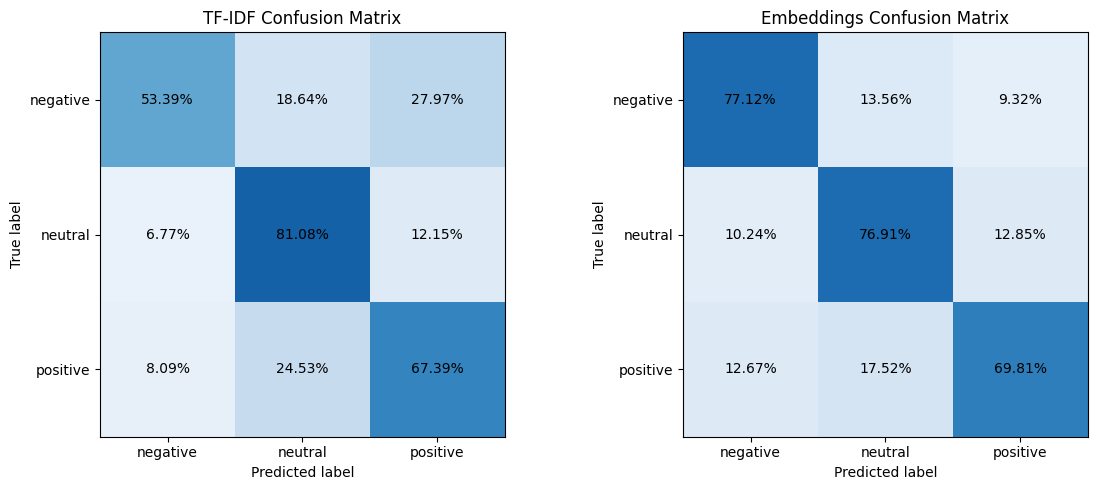

In [81]:

'''
The classification reports for both the TF-IDF and sentence embedding models are computed using `classification_report` from `scikit-learn`.
'''

report_tfidf = classification_report(
    y_test,
    y_pred_tfidf,
    output_dict=True
)

report_embedding = classification_report(
    y_test,
    y_pred_embedding,
    output_dict=True
)

metrics_summary = pd.DataFrame({
    "Model": ["TF-IDF", "Embeddings"],
    "Accuracy": [accuracy_score(y_test, y_pred_tfidf), accuracy_score(y_test, y_pred_embedding)],
    "Macro F1": [f1_score(y_test, y_pred_tfidf, average="macro"), f1_score(y_test, y_pred_embedding, average="macro")],

    "Negative Precision": [report_tfidf["negative"]["precision"],
                            report_embedding["negative"]["precision"]],
    "Negative Recall": [report_tfidf["negative"]["recall"],
                        report_embedding["negative"]["recall"]],
    "Negative F1": [report_tfidf["negative"]["f1-score"],
                    report_embedding["negative"]["f1-score"]],

    "Neutral Precision": [report_tfidf["neutral"]["precision"],
                          report_embedding["neutral"]["precision"]],
    "Neutral Recall": [report_tfidf["neutral"]["recall"],
                       report_embedding["neutral"]["recall"]],
    "Neutral F1": [report_tfidf["neutral"]["f1-score"],
                   report_embedding["neutral"]["f1-score"]],

    "Positive Precision": [report_tfidf["positive"]["precision"],
                           report_embedding["positive"]["precision"]],
    "Positive Recall": [report_tfidf["positive"]["recall"],
                        report_embedding["positive"]["recall"]],
    "Positive F1": [report_tfidf["positive"]["f1-score"],
                    report_embedding["positive"]["f1-score"]]
}, index = None)

metrics_summary = metrics_summary.round(3)
metrics_summary.to_csv(os.path.join(OUTPUT_DIR, "metrics_summary.csv"))
display(metrics_summary)

# Extra for LaTeX report
metrics_summary = metrics_summary.set_index("Model").T.reset_index()
metrics_summary.columns = ["Metric", "TFIDF", "Embedding"]
metrics_summary = metrics_summary.replace("_", " ")
metrics_summary.to_csv(os.path.join(OUTPUT_DIR, "metrics_summary_transposed.csv"), index=False)

'''
The confusion matrices for both the TF-IDF and sentence embedding models are computed using `confusion_matrix` from `scikit-learn`.
The matrices are normalized to show percentages, and then visualized using `matplotlib`.
'''

labels = clf.classes_

cm_tfidf = confusion_matrix(
    y_test,
    y_pred_tfidf,
    labels = labels
)

cm_embedding = confusion_matrix(
    y_test,
    y_pred_embedding,
    labels = labels
)

cm_tfidf = cm_tfidf / cm_tfidf.sum(axis=1, keepdims=True) * 100
cm_embedding = cm_embedding / cm_embedding.sum(axis=1, keepdims=True) * 100

def plot_cm(ax, cm, title):
    im = ax.imshow(cm,
                   cmap="Blues",
                   vmin=0,
                   vmax=100
        )

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j,
                    i,
                    f"{np.round(cm[i, j], 2)}%",
                    ha="center",
                    va="center"
            )

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

plot_cm(ax[0], cm_tfidf, "TF-IDF Confusion Matrix")
plot_cm(ax[1], cm_embedding, "Embeddings Confusion Matrix")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,
                         "confusion_matrices_comparison.png"
            )
)
plt.show()

The embedding-based model achieves slightly better overall performance compared with the TF-IDF baseline, particularly in terms of macro F1-score. The most significant improvement concerns the `negative` class, whose recall increases substantially when semantic embeddings are used.
This suggests that dense semantic representations are more effective at capturing contextual and subtle negative sentiment, whereas TF-IDF relies more heavily on explicit lexical patterns.

The confusion matrices further highlight the different behavior of the two approaches. The embedding-based model achieves a higher recall for the `negative` class, correctly identifying more than 77% of negative sentences against the 53% of TF-IDF.<br>
In contrast, the TF-IDF model has slightly stronger performance on the `neutral` class, suggesting that lexical representations may be more effective when sentiment is weak or absent. Overall, the embedding-based representation appears more reliable in capturing contextual and semantically nuanced financial sentiment, particularly for minority and implicitly negative examples.

## 8. Errors analysis

Misclassified examples are extracted to investigate systematic error patterns made by the two models. This step is essential to understand the limitations of lexical representations and to identify cases where semantic or contextual information is required.

The analysis focuses on comparing errors produced by the TF-IDF and embedding-based models, with the goal of highlighting differences in how each approach handles ambiguity, negation, and domain-specific financial language.


### 8.1 Misclassified examples extraction

Misclassified sentences are extracted separately for both models by comparing predicted and true labels.


In [82]:
errors_tfidf_df = results[
    (results["true_label"] != results["predicted_label_tfidf"])
]

errors_embedding_df = results[
    (results["true_label"] != results["predicted_label_embedding"])
]

print(f"Number of errors made by TF-IDF model: {len(errors_tfidf_df)}")
print(f"Number of errors made by Embeddings model: {len(errors_embedding_df)}")

Number of errors made by TF-IDF model: 285
Number of errors made by Embeddings model: 272


### 8.2 Disagreement-based error analysis

To gain deeper insights into the differences between lexical and semantic representations, a subset of sentences where the two models produce different predictions is analyzed.
From this subset, 10 representative examples are randomly sampled and manually inspected. These cases are particularly informative, as they highlight situations where model performance depends on the type of text representation used.


In [83]:
disagreements_df = results[
    (results["predicted_label_tfidf"] != results["predicted_label_embedding"])
]

sample_errors = disagreements_df.sample(n=10, random_state=42)
sample_errors

,sentence_id,sentence,true_label,predicted_label_tfidf,predicted_label_embedding
42,5645,$SPY Tomorrow party time for the Bears!! $GOOG and $MSFT -5.5%,negative,positive,negative
938,4878,EUR 152.4 mn of this was net interest income .,neutral,positive,neutral
620,5590,"Britain's FTSE steadies, supported by Dixons Carphone",positive,positive,neutral
811,244,"We went to the market with yield guidance of the 7.25 % area , which gave us the flexibility to go up or down by 1-8th .",neutral,neutral,positive
303,1095,"$SINA even though the ""report"" is untrue and has been proven unture, the damage is done. No one wants to touch it now",negative,neutral,negative
885,823,The new technology improves the glass quality and consistency while increasing throughput .,positive,neutral,positive
982,3718,"As a result , the Russia 's import restrictions on Finnish dairy companies will be canceled on 6 August 2010 .",positive,neutral,negative
660,4324,Oriola-KD expects its invoicing in 2008 to be higher than the comparable invoicing of 2007 .,positive,neutral,positive
176,1137,"After the takeover , Cramo will become the second largest rental services provider in the Latvian market .",positive,positive,neutral
856,441,$ISRG - ISRG Short - http://stks.co/f1vVU http://stks.co/c1qrm,negative,negative,neutral


In [84]:
# Extra for LaTeX report

latex_code = sample_errors.to_latex()

with open(os.path.join(OUTPUT_DIR, "errors_table.tex"), "w") as f:
    f.write(latex_code)


# Adding comments

sample_errors["comment"] = [
    "TF-IDF misinterprets sarcasm and market slang ('party time for the Bears') as positive due to the lack of explicit negative indicators.",
    
    "TF-IDF overweights numerical and financial magnitude ('152.4 mn', 'interest income') leading to an optimistic bias.",
    
    "Embeddings model underestimates the positive implications of market steadiness.",
    
    "Yield-related financial jargon confuses embeddings, which interpret uncertainty as positive signal.",

    "TF-IDF fails to capture negation and reputational damage context ('damage is done'), leading to a neutral prediction.",
    
    "TF-IDF misses the implicit positive evaluation in the description of technical improvement.",
    
    "Both models struggle to capture the positive sentiment associated with the end of import restrictions. The embedding model may overfocus on terms such as 'restrictions' and 'canceled'.",
    
    "Forecasting language may have confused TF-IDF.",
    
    "The embedding model fails to recognize the positive market implications of the takeover.",
    
    "The embedding model fails to contextualize the term 'short' as a bearish financial position."
]


sample_errors.to_csv(os.path.join(OUTPUT_DIR, "commented_sample_model_errors.csv"), index = False)





# sample_errors.to_csv(os.path.join(OUTPUT_DIR, "commented_errors_clean.csv"), index = False)


## 9. Conclusion

Both models achieve satisfactory performance on the financial sentiment classification task, although they exhibit different strengths and weaknesses.

The TF-IDF model performs generally well and remains highly interpretable, but due to its architecture it struggles with contextual meaning, implicit sentiment, and financial ambiguity. This may be the main reason why the model struggles more often with the negative class: negative financial news is often expressed in a less direct way than other sentiments, sometimes through subtle wording, sarcasm or metaphors.

In contrast, the embedding-based approach demonstrates better generalization capabilities and improved performance on the minority negative class, suggesting that semantic representations are more effective at capturing subtle financial language. Still, it is important to note the higher computational cost required by this model compared with TF-IDF, whose efficiency remains one of its main advantages.

In conclusion, although embedding-based model achieves overall better performance, model selection should also take into account other factors, such as dataset structure, computational constraints and whether the expected performance improvement justifies the additional resource demand.
